# Physiological Sepsis Phenotyping for Pitt Data 
## Step 1: Comprehensive feature extraction table for wave matched sepsis patient encounters (fin 2016-2022) for pre-sepsis region in 5 min segments uptill 6 hours




In [1]:
import pandas as pd
from datetime import datetime
import os
import numpy as np
import wfdb
from scipy.io import loadmat
import glob
import h5py
import json
import matplotlib.pyplot as plt
import time
# from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import resampy

import MPT as mpt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_sepsis_wavmatched = pd.read_csv('Data_folder/df_step0_WaveMatchedSepsisPats_table.csv')







In [3]:
len(df_sepsis_wavmatched.fin.unique())

4041

In [ ]:
df_sepsis_wavmatched

In [5]:
df_sepsis_wavmatched.drop(columns='Unnamed: 0', axis=1, inplace=True)


In [6]:
df_sepsis_wavmatched.columns


Index(['fin', 'year_sepsis', 't_sepsis', 'result_val_SpO2', 'result_val_PAO2',
       'result_val_Glasgow_Coma_Score', 'result_val_Mean_blood_pressure', 'PF',
       'SF', 'result_val_norepinephrine', 'result_val_DOBUTamine',
       'result_val_DOPamine', 'result_val_EPINEPHrine', 'result_val_Bilirubin',
       'result_val_Creatinine', 'result_val_Platelets', 'result_val_FIO2',
       'val_cardio', 'val_cardio_mod', 'val_neuro', 'val_hep', 'val_renal',
       'val_coag', 'val_resp', 'sofa', 'hourly', 'waveID', 'parts', 'studyID',
       'date_updated'],
      dtype='object')

In [7]:
def tc_wave_process(pat_data, tsepsis3, Tstart, W_sec, fs_empi, fs_resamp, signal_id): ### signal_id='II'
    signal_time0 = pd.to_timedelta(pat_data['data']['waveforms'][signal_id][0][0])
    delT_signal = tsepsis3 - (Tstart + signal_time0)
    # print((i, 'delT_ecg, tsepsis3, Tstart, ecg_time0', delT_ecg, tsepsis3, Tstart, ecg_time0))
    SepsisSec_signal = int(delT_signal.total_seconds()) #in seconds
    st1, ed1 = SepsisSec_signal*fs_empi - 6*60*60*fs_empi, SepsisSec_signal*fs_empi + 1000
    dfsignal = pd.DataFrame(pat_data['data']['waveforms'][signal_id][st1 : ed1]) #Cropping approximately
    fs_signal = int(np.round(1/dfsignal.time[:30000].diff().median()))
    t_SepsisIdx_signal = int(np.floor(SepsisSec_signal*fs_signal))-int(st1) #in samples from st1
    preSep_sample_size_signal = W_sec*fs_signal #15 mins prior to sepsis-3 time
    pre_t_SepsisIdx_signal = t_SepsisIdx_signal-preSep_sample_size_signal
    sig_range_signal = np.arange(pre_t_SepsisIdx_signal, t_SepsisIdx_signal) #For cropping precisely
    '''
    * Consider to avoid gaps/breaks in the time-vector-->
    * Make sure the linear increment of time in sig_range: if linearity breaks at any point from end (i.e. t_SepsisIdx_signal),
      truncate the segment as sig_range_signal = np.arange(truncatedIdx_signal, t_SepsisIdx_signal)
    * Don't believe on correct estimation of PTT and dPTT with this setting
    '''    
    timeVec = dfsignal.time[sig_range_signal]
    dtimeVec = timeVec.diff()
    dtimeVec.reset_index(drop=True, inplace=True)
    dtimeVec.iloc[0] = dtimeVec.iloc[1]
    cond1 = dtimeVec < (1/fs_signal)-(0.50*1/fs_signal)
    cond2 = dtimeVec > (1/fs_signal)+(0.50*1/fs_signal)
    indxx = np.where(cond1 | cond2)[0]
    if len(indxx)==0: pass
    elif len(indxx)==1: sig_range_signal = np.arange(pre_t_SepsisIdx_signal + indxx, t_SepsisIdx_signal)
    else: sig_range_signal = np.arange(pre_t_SepsisIdx_signal + indxx[-1], t_SepsisIdx_signal)

    signal = dfsignal.value.values
    signal_seg = signal[sig_range_signal]
    signal_seg = resampy.resample(signal_seg, fs_signal, fs_resamp) #Resampling to fs_resamp
    return signal, signal_seg

In [8]:
columns = ['index','segmentID','waveID', 'fin', 'year_sepsis', 'studyID', 't_origin', 't_sepsis','sofa',
       'T_rr_ms', 'HR_bpm', 'edr_rate_Bpm', 'atrialSys_phase', 'ventSys_phase',
       'P_duration', 'QRS_duration', 'T_duration', 'pr_interval_ms',
       'pr_segment_ms', 'st_interval_ms', 'st_segment_ms', 'qt_interval_ms',
       'qtc_interval_ms', 'ecgBeatCenterFreq', 'ecgInterbeat_eigval1',
       'ecgInterbeat_eigval2', 'ecgInterbeat_eigval3', 'HRV_rqa_REC',
       'HRV_rqa_DET', 'HRV_rqa_LAM', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1',
       'HRV_SDNNI1', 'HRV_SDANN2', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5',
       'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN',
       'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN',
       'HRV_Prc80NN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI',
        'HRV_TINN', 'HRV_ULF', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF',
        'HRV_TP', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1',
        'HRV_SD2', 'HRV_SD1SD2', 'HRV_S', 'HRV_CSI', 'HRV_CVI',
        'HRV_CSI_Modified', 'HRV_PIP', 'HRV_IALS', 'HRV_PSS', 'HRV_PAS',
        'HRV_GI', 'HRV_SI', 'HRV_AI', 'HRV_PI', 'HRV_C1d', 'HRV_C1a',
        'HRV_SD1d', 'HRV_SD1a', 'HRV_C2d', 'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a',
        'HRV_Cd', 'HRV_Ca', 'HRV_SDNNd', 'HRV_SDNNa', 'HRV_DFA_alpha1',
        'HRV_MFDFA_alpha1_Width', 'HRV_MFDFA_alpha1_Peak',
        'HRV_MFDFA_alpha1_Mean', 'HRV_MFDFA_alpha1_Max',
        'HRV_MFDFA_alpha1_Delta', 'HRV_MFDFA_alpha1_Asymmetry',
        'HRV_MFDFA_alpha1_Fluctuation', 'HRV_MFDFA_alpha1_Increment',
        'HRV_DFA_alpha2', 'HRV_MFDFA_alpha2_Width', 'HRV_MFDFA_alpha2_Peak',
        'HRV_MFDFA_alpha2_Mean', 'HRV_MFDFA_alpha2_Max',
        'HRV_MFDFA_alpha2_Delta', 'HRV_MFDFA_alpha2_Asymmetry',
        'HRV_MFDFA_alpha2_Fluctuation', 'HRV_MFDFA_alpha2_Increment',
        'HRV_ApEn', 'HRV_SampEn', 'HRV_ShanEn', 'HRV_FuzzyEn', 'HRV_MSEn',
        'HRV_CMSEn', 'HRV_RCMSEn', 'HRV_CD', 'HRV_HFD', 'HRV_KFD', 'HRV_LZC',
        'MSE_0', 'MSE_1', 'MSE_2', 'MSE_3', 'MSE_4', 'MSE_5', 'MSE_6', 'MSE_7',
        'MSE_8', 'MSE_9', 'MSE_10', 'MSE_11', 'MSE_12', 'MSE_13', 'MSE_14',
        'MSE_15', 'MSE_16', 'MSE_17', 'MSE_18', 'MSE_19', 'AUC_pulse_nu',
        'AUC_sys_nu', 'AUC_dias_nu', 'IPA', 'AUCow_nu', 'AUCwo_nu', 'AUCos_nu',
        'AUCso_nu', 'Tsys_ms', 'Tdias_ms', 'T_ow_ms', 'T_wo_ms', 'T_os_ms',
        'T_so_ms', 'T_so_cd_ms', 'A_AC', 'A_off', 'A_sp', 'DN_exists', 'A_dn',
        'Ton_off_ms', 'Tsp_sp_ms', 'PR', 'mean_slope_os', 'mean_slope_so',
        'Delta_T_sd', 'RI', 'SI','Delta_A_dn_dp', 'T_dn_dp_ms', 'ppg_class', 'max_upslope', 'pat_ms',
        'dpat_ms', 'Delta_A_sp_sp', 'Augmentation_index', 'center_freq_ppg_Hz',
        'mean_ppg', 'median_ppg', 'variance_ppg', 'skewness_ppg',
        'kurtosis_ppg', 'std_ppg', 'entropy_ppg', 'energy_ppg', 'PW_10',
        'PW_25', 'PW_33', 'PW_50', 'PW_66', 'PW_75', 'ppgBeatCenterFreq',
        'ppgInterbeat_eigval1', 'ppgInterbeat_eigval2', 'ppgInterbeat_eigval3',
        'insp_time', 'exp_time', 'insp_exp_ratio', 'resp_width_PPresp_s',
        'resp_rate_Bpm', 'SBP', 'DBP', 'HR_ABP', 'MAP', 'PP_ABP', 'CO', 'TPR','ShockIndex','status']

In [9]:
################### New latest: Upto 5 mins prior to index sepsis-3 #############################################

##pooling and processing
def final_run(i): 
    h = 0 #segmentID initialized
    AllSuperTable = pd.DataFrame([], columns=columns)
    path_wave = '../../../../../ix1/mladi/work/extracted/'
    tsepsis3 = pd.to_datetime(df_sepsis_wavmatched['t_sepsis'].iloc[i])
    path_pat = path_wave + df_sepsis_wavmatched['waveID'].iloc[i]
    df_sepsis_wavmatched['t_origin'] = np.nan
    try:
        pat_data = h5py.File(path_pat, 'r') 
        Tstart = pd.to_datetime(json.loads(pat_data.attrs['.meta'])['time_origin'][:-4]) #.tz_localize(None)
        df_sepsis_wavmatched['t_origin'].iloc[i] = Tstart
        fs = 1000 ## ---- Resampling frequency
        W_sec = 6*60*60 ### ----- presepsis data duration used for study
        L_sec = 5*60 ### ------- 5 mins of presepsis data segments
        
        delT = tsepsis3 - Tstart
        # Since we are interesed for the data prior to first sepsis-3 time
        if delT.days >= 0:     
            try:
                ecg_long, ecg_seg_long = tc_wave_process(pat_data, tsepsis3, Tstart, W_sec=W_sec, fs_empi=500, fs_resamp=fs, signal_id='II')       
            except ValueError: ecg_long, ecg_seg_long = [], [] #print('ECG is unavailable!') ''' ValueError, if sig_name doesn't carry given index'''
            except IndexError: ecg_long, ecg_seg_long = [], [] #print('ECG is unavailable!') ''' IndexError, if sig_range is beyond the limits of signal samples''' 
            except KeyError: ecg_long, ecg_seg_long = [], []

            try:
                ppg_long, ppg_seg_long = tc_wave_process(pat_data, tsepsis3, Tstart, W_sec=W_sec, fs_empi=125, fs_resamp=fs, signal_id='Pleth')       
            except ValueError: ppg_long, ppg_seg_long = [], [] #print('ECG is unavailable!') ''' ValueError, if sig_name doesn't carry given index'''
            except IndexError: ppg_long, ppg_seg_long = [], [] #print('ECG is unavailable!') ''' IndexError, if sig_range is beyond the limits of signal samples''' 
            except KeyError: ppg_long, ppg_seg_long = [], []

            try:
                resp_long, resp_seg_long = tc_wave_process(pat_data, tsepsis3, Tstart, W_sec=W_sec, fs_empi=62, fs_resamp=fs, signal_id='Resp')       
            except ValueError: resp_long, resp_seg_long = [], [] #print('ECG is unavailable!') ''' ValueError, if sig_name doesn't carry given index'''
            except IndexError: resp_long, resp_seg_long = [], [] #print('ECG is unavailable!') ''' IndexError, if sig_range is beyond the limits of signal samples''' 
            except KeyError: resp_long, resp_seg_long = [], []

            try:
                abp_long, abp_seg_long = tc_wave_process(pat_data, tsepsis3, Tstart, W_sec=W_sec, fs_empi=125, fs_resamp=fs, signal_id='ABP')               
            except ValueError: abp_long, abp_seg_long = [], [] #print('ECG is unavailable!') ''' ValueError, if sig_name doesn't carry given index'''
            except IndexError: abp_long, abp_seg_long = [], [] #print('ECG is unavailable!') ''' IndexError, if sig_range is beyond the limits of signal samples''' 
            except KeyError: abp_long, abp_seg_long = [], []

            pat_data.close()
            
            ecg = ecg_seg_long
            ppg = ppg_seg_long
            resp = resp_seg_long
            abp = abp_seg_long
            
            for h in range(int(W_sec/L_sec)): #range(int(6*60/5)):   #### 6hrs of data in every 5min segments = 72
                # h acts as segment ID here for a given patient id i.

                if h==0: ecg_seg = ecg[-(h+1)*L_sec*fs:]
                else: ecg_seg = ecg[-(h+1)*L_sec*fs : -h*L_sec*fs]

                if h==0: ppg_seg = ppg[-(h+1)*L_sec*fs:]
                else: ppg_seg = ppg[-(h+1)*L_sec*fs : -h*L_sec*fs]

                if h==0: resp_seg = resp[-(h+1)*L_sec*fs:]
                else: resp_seg = resp[-(h+1)*L_sec*fs : -h*L_sec*fs]

                if h==0: abp_seg = abp[-(h+1)*L_sec*fs:]
                else: abp_seg = abp[-(h+1)*L_sec*fs : -h*L_sec*fs]
            
                '''
                Ensure each signal duration must last >5s
                '''
                if len(ecg_seg) < 5*fs: ecg, ecg_seg = [], []
                if len(ppg_seg) < 5*fs: ppg, ppg_seg = [], []
                if len(resp_seg) < 5*fs: resp, resp_seg = [], []
                if len(abp_seg) < 5*fs: abp, abp_seg = [], []
            
            
                '''
                Ensure time-synchrony of signals and crop from sepsis time (reversely) to make signal lengths equal.
                '''
                signal_segLen = [len(ecg_seg), len(ppg_seg), len(resp_seg), len(abp_seg)]
                nonzero_sig_i = np.where(signal_segLen)[0] #checking which signal is having nonzero length
                if len(nonzero_sig_i) > 0:
                    zero_sig_i = list(set(np.arange(4)) - set(np.where(signal_segLen)[0])) #Signals having zero length
                    zero_sig_i = np.asarray(zero_sig_i, dtype=int)
                    if len(zero_sig_i)>0:
                        for dd in zero_sig_i:
                            signal_segLen[dd] = 99e150 #Maximum arbitrary
                    sig_i = np.argmin(signal_segLen)

                    if sig_i == 0:
                        minLen = len(ecg_seg)
                        ppg_seg = ppg_seg[-minLen:]
                        resp_seg = resp_seg[-minLen:]
                        abp_seg = abp_seg[-minLen:]
                    elif sig_i == 1:
                        minLen = len(ppg_seg)
                        ecg_seg = ecg_seg[-minLen:]
                        resp_seg = resp_seg[-minLen:]
                        abp_seg = abp_seg[-minLen:]
                    elif sig_i == 2:
                        minLen = len(resp_seg)
                        ppg_seg = ppg_seg[-minLen:]
                        ecg_seg = ecg_seg[-minLen:]
                        abp_seg = abp_seg[-minLen:]
                    elif sig_i == 3:
                        minLen = len(abp_seg)
                        ppg_seg = ppg_seg[-minLen:]
                        resp_seg = resp_seg[-minLen:]
                        ecg_seg = ecg_seg[-minLen:]
            
                '''
                Execute the following if atleast one signal is present
                '''
                if np.array([len(ecg), len(ppg), len(resp), len(abp)]).any():  
                    P = mpt.physiomarkers_from_biosignals(ecg_seg, ppg_seg, resp_seg, abp_seg, fs, Show_plotly=False, Show_matplotlib=False)
                    P.FiducialpointDetect_with_SQA(F_s=1000)
                    flat_ecg_cond = len(ecg)==0 or np.sum(P.flatline['flat_loc_ecg'])/len(P.flatline['flat_loc_ecg']) > 0.80  ### To be considered as a flatline
                    flat_ppg_cond = len(ppg)==0 or np.sum(P.flatline['flat_loc_ppg'])/len(P.flatline['flat_loc_ppg']) > 0.80
                    flat_resp_cond = len(resp)==0 or np.sum(P.flatline['flat_loc_resp'])/len(P.flatline['flat_loc_resp']) > 0.80
                    flat_abp_cond = len(abp)==0 or np.sum(P.flatline['flat_loc_abp'])/len(P.flatline['flat_loc_abp']) > 0.80
                    if np.array([flat_ecg_cond, flat_ppg_cond, flat_resp_cond, flat_abp_cond]).all(): 
                        feat_df_extended = pd.DataFrame([{
                            'index': i,
                            'fin':df_sepsis_wavmatched.iloc[i]['fin'],
                            'segmentID': h,
                            'record_name': debed,
                            'status': 'no_signals'
                        }], columns=columns)
                        AllSuperTable = pd.concat([AllSuperTable, feat_df_extended], ignore_index=True)
                        # print((f'Row index {i}:Either no signals or all are flat in RoI!'))
                    else: 
                        
                        physiomarkers_all = P.feature_extraction() 
                        # Flatten nested dictionary
                        flat_dict = {}
                        for modality, features in physiomarkers_all.items():
                            for feat_name, feat_value in features.items():
                                flat_dict[f"{feat_name}"] = feat_value
                        # Convert to DataFrame
                        feat_df = pd.DataFrame([flat_dict])
                        z = pd.DataFrame(df_sepsis_wavmatched.iloc[i]).T
                        z.reset_index(drop=True, inplace=True)
                        feat_df.reset_index(drop=True, inplace=True)
                        feat_df_extended = pd.concat([z, feat_df], axis=1)
                        feat_df_extended['index'] = [i]
                        feat_df_extended['segmentID'] = [h]
                        feat_df_extended['status'] = ['perfect']
                        feat_df_extended = feat_df_extended[columns]
                        AllSuperTable = pd.concat([AllSuperTable, feat_df_extended], ignore_index=True)
                else: 
                    feat_df_extended = pd.DataFrame([], columns=columns)
                    feat_df_extended['fin'] = [df_sepsis_wavmatched.iloc[i]['fin']]
                    feat_df_extended['index'] = [i]
                    feat_df_extended['segmentID'] = [h]
                    feat_df_extended['status'] = ['no_signals']
                    AllSuperTable = pd.concat([AllSuperTable, feat_df_extended], ignore_index=True)
                    # print((f'Row index {i}: No signal is present in RoI!'))
                    pass
               
        else: 
            feat_df_extended = pd.DataFrame([], columns=columns)
            feat_df_extended['fin'] = [df_sepsis_wavmatched.iloc[i]['fin']]
            feat_df_extended['index'] = [i]
            feat_df_extended['segmentID'] = [h]
            feat_df_extended['status'] = ['delT_neg']
            AllSuperTable = pd.concat([AllSuperTable, feat_df_extended], ignore_index=True)
            # print((f'Row index {i}: Delta-T is negative!'))
            pass
                   
    
    except (FileNotFoundError, UnboundLocalError, ValueError, IndexError, TypeError, KeyError, AttributeError, ZeroDivisionError, SystemError) as e: 
        error_map = {ValueError: 'value_err',
            IndexError: 'index_err',
            FileNotFoundError: 'fileOrHeader_missing',
            TypeError: 'type_err',
            UnboundLocalError: 'unboundLocal',
            AttributeError: 'attributeErr',
            KeyError: 'KeyError'}
        error_type = error_map.get(type(e), 'other_err')  # Default to 'other_err' if not mapped
        #print(f"Error in id {i}: {type(e).__name__}")
        feat_df_extended = pd.DataFrame([{
            'index': i,
            'fin': df_sepsis_wavmatched.iloc[i]['fin'],
            'segmentID': h,
            'status': error_type
        }], columns=columns)
        AllSuperTable = pd.concat([AllSuperTable, feat_df_extended], ignore_index=True)
    
    if i % 200 == 0:
        print(f"Id {i} completed")
    return AllSuperTable 

# start = time.time()
# p = Pool(40)
# results = p.map(final_run, range(len(df_sepsis_wavmatched)) ) #range(len(df_sepsis_wavmatched))
# p.close()
# p.join()        
# AllSuperTable_1 = pd.concat(results, ignore_index=True)
# end = time.time()
# print('Completed in: %s sec.'%(end - start))
# display(AllSuperTable_1)

In [10]:
L = len(df_sepsis_wavmatched)
L

4041

In [11]:
### Batchwise operations in 3 batches
range1 = range(0, int(np.floor(L/3)))
range2 = range(int(np.floor(L/3)),  int(np.floor(2*L/3)))
range3 = range(int(np.floor(2*L/3)),  L)
range1, range2, range3

(range(0, 1347), range(1347, 2694), range(2694, 4041))

In [12]:
import gc
if __name__ == '__main__':
    start_total = time.time()

    with ProcessPoolExecutor(max_workers=10) as executor:
        # print("Starting Batch 1...")
        # results1 = list(executor.map(final_run, range1))
        # AllSuperTable_1 = pd.concat(results1, ignore_index=True)
        # del results1
        # gc.collect()

#         print("Starting Batch 2...")
#         results2 = list(executor.map(final_run, range2))
#         AllSuperTable_2 = pd.concat(results2, ignore_index=True)
#         del results2
#         gc.collect()

        print("Starting Batch 3...")
        results3 = list(executor.map(final_run, range3))
        AllSuperTable_3 = pd.concat(results3, ignore_index=True)
        del results3
        gc.collect()

    # # Combine all final results
    # FinalSuperTable = pd.concat(
    #     [AllSuperTable_1, AllSuperTable_2, AllSuperTable_3],
    #     ignore_index=True
    # )

    end_total = time.time()
    print(f"All batches completed in {end_total - start_total:.2f} seconds.")
    # display(FinalSuperTable)
    
    AllSuperTable_3.to_csv('AllSuperTable_batch3.csv')

Starting Batch 3...
Id 3000 completed
Id 3200 completed
Id 3400 completed
Id 3600 completed
Id 3800 completed
Id 4000 completed
All batches completed in 7618.19 seconds.


In [ ]:
import gc
if __name__ == '__main__':
    start_total = time.time()

    with ProcessPoolExecutor(max_workers=40) as executor:
        print("Starting Batch 1...")
        results1 = list(executor.map(final_run, range1))
        AllSuperTable_1 = pd.concat(results1, ignore_index=True)
        del results1
        gc.collect()

        print("Starting Batch 2...")
        results2 = list(executor.map(final_run, range2))
        AllSuperTable_2 = pd.concat(results2, ignore_index=True)
        del results2
        gc.collect()

        print("Starting Batch 3...")
        results3 = list(executor.map(final_run, range3))
        AllSuperTable_3 = pd.concat(results3, ignore_index=True)
        del results3
        gc.collect()

    # Combine all final results
    FinalSuperTable = pd.concat(
        [AllSuperTable_1, AllSuperTable_2, AllSuperTable_3],
        ignore_index=True
    )

    end_total = time.time()
    print(f"All batches completed in {end_total - start_total:.2f} seconds.")
    display(FinalSuperTable)

In [18]:
228015/72

3166.875

In [14]:
len(FinalSuperTable)

133872

In [ ]:
#228015

# Saving

In [9]:
# FinalSuperTable.to_csv('Data_folder/df_step1_physiomarkers_presepsis6hrs_5minWindow_new_v2.csv')










FinalSuperTable = pd.read_csv('Data_folder/df_step1_physiomarkers_presepsis6hrs_5minWindow_new_v2.csv')

In [10]:
FinalSuperTable.status.value_counts()

no_signals              110286
perfect                  21271
KeyError                  1267
fileOrHeader_missing       572
delT_neg                   262
value_err                  155
index_err                   55
other_err                    4
Name: status, dtype: int64

In [ ]:
FinalSuperTable

In [ ]:
# Previously: len(): 228015

# no_signals              198166
# perfect                  28945
# fileOrHeader_missing       572
# delT_neg                   262
# index_err                   64
# value_err                    6

In [11]:
FinalSuperTable.fin.nunique()

4041

Text(0, 0.5, 'Count')

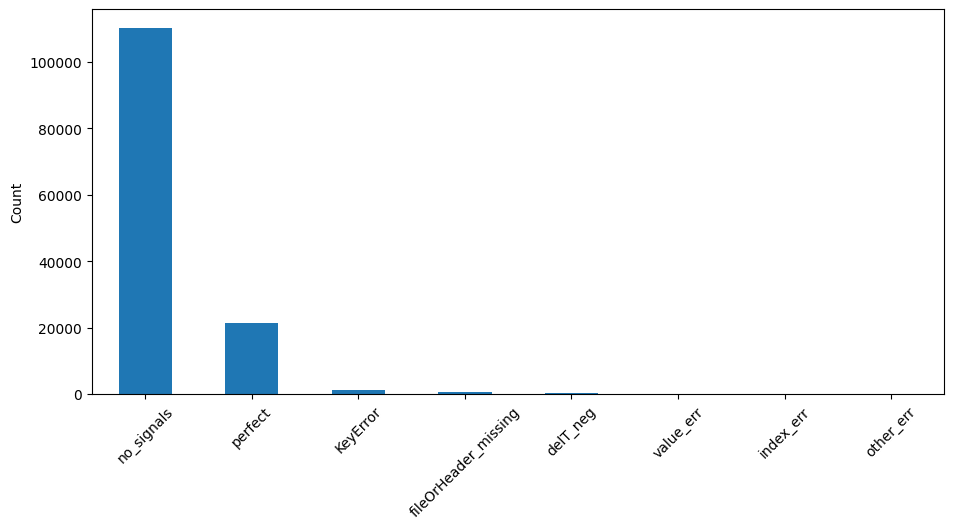

In [12]:
plt.figure(figsize=(11,5))
# AllSuperTable_1.status.hist(barsize=0.3)
FinalSuperTable['status'].value_counts().plot(kind='bar', rot=45)
plt.ylabel('Count')

In [13]:
# AllSuperTable_1.T_rr_ms, AllSuperTable_1.PR, AllSuperTable_1.resp_rate_Bpm, AllSuperTable_1.SBP, AllSuperTable_1.TPR


In [ ]:
FinalSuperTable[FinalSuperTable.status=='value_err']


In [15]:
FinalSuperTable.studyID.nunique(), FinalSuperTable.fin.nunique(), FinalSuperTable.fin.nunique(), FinalSuperTable.shape


(1561, 4041, 4041, (133872, 211))

In [16]:
len(FinalSuperTable[FinalSuperTable.status=='perfect'].studyID.unique()), len(FinalSuperTable[FinalSuperTable.status=='perfect'].fin.unique())

(1561, 1598)

In [17]:
print(FinalSuperTable.T_rr_ms.isnull().sum(), #ECGs missing
      FinalSuperTable.PR.isnull().sum(), #PPGs missing
      FinalSuperTable.resp_rate_Bpm.isnull().sum(),
      FinalSuperTable.SBP.isnull().sum())#ABPs missing

115942 115223 112868 132074


In [18]:
FinalSuperTable[FinalSuperTable.status=='value_err'].shape

(155, 211)

In [ ]:
FinalSuperTable[FinalSuperTable.status=='value_err'].index[:100]

# Individual Testing

In [ ]:
FinalSuperTable[FinalSuperTable.status=='value_err']

In [27]:
################### New latest: Upto 5 mins prior to index sepsis-3 #############################################

columns = ['index','segmentID','waveID', 'fin', 'year_sepsis', 'studyID', 't_origin', 't_sepsis','sofa',
       'T_rr_ms', 'HR_bpm', 'edr_rate_Bpm', 'atrialSys_phase', 'ventSys_phase',
       'P_duration', 'QRS_duration', 'T_duration', 'pr_interval_ms',
       'pr_segment_ms', 'st_interval_ms', 'st_segment_ms', 'qt_interval_ms',
       'qtc_interval_ms', 'ecgBeatCenterFreq', 'ecgInterbeat_eigval1',
       'ecgInterbeat_eigval2', 'ecgInterbeat_eigval3', 'HRV_rqa_REC',
       'HRV_rqa_DET', 'HRV_rqa_LAM', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1',
       'HRV_SDNNI1', 'HRV_SDANN2', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5',
       'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN',
       'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN',
       'HRV_Prc80NN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI',
        'HRV_TINN', 'HRV_ULF', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF',
        'HRV_TP', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1',
        'HRV_SD2', 'HRV_SD1SD2', 'HRV_S', 'HRV_CSI', 'HRV_CVI',
        'HRV_CSI_Modified', 'HRV_PIP', 'HRV_IALS', 'HRV_PSS', 'HRV_PAS',
        'HRV_GI', 'HRV_SI', 'HRV_AI', 'HRV_PI', 'HRV_C1d', 'HRV_C1a',
        'HRV_SD1d', 'HRV_SD1a', 'HRV_C2d', 'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a',
        'HRV_Cd', 'HRV_Ca', 'HRV_SDNNd', 'HRV_SDNNa', 'HRV_DFA_alpha1',
        'HRV_MFDFA_alpha1_Width', 'HRV_MFDFA_alpha1_Peak',
        'HRV_MFDFA_alpha1_Mean', 'HRV_MFDFA_alpha1_Max',
        'HRV_MFDFA_alpha1_Delta', 'HRV_MFDFA_alpha1_Asymmetry',
        'HRV_MFDFA_alpha1_Fluctuation', 'HRV_MFDFA_alpha1_Increment',
        'HRV_DFA_alpha2', 'HRV_MFDFA_alpha2_Width', 'HRV_MFDFA_alpha2_Peak',
        'HRV_MFDFA_alpha2_Mean', 'HRV_MFDFA_alpha2_Max',
        'HRV_MFDFA_alpha2_Delta', 'HRV_MFDFA_alpha2_Asymmetry',
        'HRV_MFDFA_alpha2_Fluctuation', 'HRV_MFDFA_alpha2_Increment',
        'HRV_ApEn', 'HRV_SampEn', 'HRV_ShanEn', 'HRV_FuzzyEn', 'HRV_MSEn',
        'HRV_CMSEn', 'HRV_RCMSEn', 'HRV_CD', 'HRV_HFD', 'HRV_KFD', 'HRV_LZC',
        'MSE_0', 'MSE_1', 'MSE_2', 'MSE_3', 'MSE_4', 'MSE_5', 'MSE_6', 'MSE_7',
        'MSE_8', 'MSE_9', 'MSE_10', 'MSE_11', 'MSE_12', 'MSE_13', 'MSE_14',
        'MSE_15', 'MSE_16', 'MSE_17', 'MSE_18', 'MSE_19', 'AUC_pulse_nu',
        'AUC_sys_nu', 'AUC_dias_nu', 'IPA', 'AUCow_nu', 'AUCwo_nu', 'AUCos_nu',
        'AUCso_nu', 'Tsys_ms', 'Tdias_ms', 'T_ow_ms', 'T_wo_ms', 'T_os_ms',
        'T_so_ms', 'T_so_cd_ms', 'A_AC', 'A_off', 'A_sp', 'DN_exists', 'A_dn',
        'Ton_off_ms', 'Tsp_sp_ms', 'PR', 'mean_slope_os', 'mean_slope_so',
        'Delta_T_sd', 'RI', 'SI','Delta_A_dn_dp', 'T_dn_dp_ms', 'ppg_class', 'max_upslope', 'pat_ms',
        'dpat_ms', 'Delta_A_sp_sp', 'Augmentation_index', 'center_freq_ppg_Hz',
        'mean_ppg', 'median_ppg', 'variance_ppg', 'skewness_ppg',
        'kurtosis_ppg', 'std_ppg', 'entropy_ppg', 'energy_ppg', 'PW_10',
        'PW_25', 'PW_33', 'PW_50', 'PW_66', 'PW_75', 'ppgBeatCenterFreq',
        'ppgInterbeat_eigval1', 'ppgInterbeat_eigval2', 'ppgInterbeat_eigval3',
        'insp_time', 'exp_time', 'insp_exp_ratio', 'resp_width_PPresp_s',
        'resp_rate_Bpm', 'SBP', 'DBP', 'HR_ABP', 'MAP', 'PP_ABP', 'CO', 'TPR','ShockIndex','status']
        
          



i = 4002
h = 1 #segmentID initialized
AllSuperTable = pd.DataFrame([], columns=columns)
path_wave = '../../../../../ix1/mladi/work/extracted/'
tsepsis3 = pd.to_datetime(df_sepsis_wavmatched['t_sepsis'].iloc[i])
path_pat = path_wave + df_sepsis_wavmatched['waveID'].iloc[i]
df_sepsis_wavmatched['t_origin'] = np.nan
try:
    pat_data = h5py.File(path_pat, 'r') 
    Tstart = pd.to_datetime(json.loads(pat_data.attrs['.meta'])['time_origin'][:-4]) #.tz_localize(None)
    df_sepsis_wavmatched['t_origin'].iloc[i] = Tstart
    fs = 1000 ## ---- Resampling frequency
    W_sec = 6*60*60 ### ----- presepsis data duration used for study
    L_sec = 5*60 ### ------- 5 mins of presepsis data segments

    delT = tsepsis3 - Tstart
    # Since we are interesed for the data prior to first sepsis-3 time
    if delT.days >= 0:     
        try:
            ecg_long, ecg_seg_long = tc_wave_process(pat_data, tsepsis3, Tstart, W_sec=W_sec, fs_empi=500, fs_resamp=fs, signal_id='II')       
        except ValueError: ecg_long, ecg_seg_long = [], [] #print('ECG is unavailable!') ''' ValueError, if sig_name doesn't carry given index'''
        except IndexError: ecg_long, ecg_seg_long = [], [] #print('ECG is unavailable!') ''' IndexError, if sig_range is beyond the limits of signal samples''' 
        except KeyError: ecg_long, ecg_seg_long = [], []

        try:
            ppg_long, ppg_seg_long = tc_wave_process(pat_data, tsepsis3, Tstart, W_sec=W_sec, fs_empi=125, fs_resamp=fs, signal_id='Pleth')       
        except ValueError: ppg_long, ppg_seg_long = [], [] #print('ECG is unavailable!') ''' ValueError, if sig_name doesn't carry given index'''
        except IndexError: ppg_long, ppg_seg_long = [], [] #print('ECG is unavailable!') ''' IndexError, if sig_range is beyond the limits of signal samples''' 
        except KeyError: ppg_long, ppg_seg_long = [], []

        try:
            resp_long, resp_seg_long = tc_wave_process(pat_data, tsepsis3, Tstart, W_sec=W_sec, fs_empi=62, fs_resamp=fs, signal_id='Resp')       
        except ValueError: resp_long, resp_seg_long = [], [] #print('ECG is unavailable!') ''' ValueError, if sig_name doesn't carry given index'''
        except IndexError: resp_long, resp_seg_long = [], [] #print('ECG is unavailable!') ''' IndexError, if sig_range is beyond the limits of signal samples''' 
        except KeyError: resp_long, resp_seg_long = [], []

        try:
            abp_long, abp_seg_long = tc_wave_process(pat_data, tsepsis3, Tstart, W_sec=W_sec, fs_empi=125, fs_resamp=fs, signal_id='ABP')               
        except ValueError: abp_long, abp_seg_long = [], [] #print('ECG is unavailable!') ''' ValueError, if sig_name doesn't carry given index'''
        except IndexError: abp_long, abp_seg_long = [], [] #print('ECG is unavailable!') ''' IndexError, if sig_range is beyond the limits of signal samples''' 
        except KeyError: abp_long, abp_seg_long = [], []

        pat_data.close()

        ecg = ecg_seg_long
        ppg = ppg_seg_long
        resp = resp_seg_long
        abp = abp_seg_long

        for h in range(int(W_sec/L_sec)): #range(int(6*60/5)):   #### 6hrs of data in every 5min segments = 72
            # h acts as segment ID here for a given patient id i.

            if h==0: ecg_seg = ecg[-(h+1)*L_sec*fs:]
            else: ecg_seg = ecg[-(h+1)*L_sec*fs : -h*L_sec*fs]

            if h==0: ppg_seg = ppg[-(h+1)*L_sec*fs:]
            else: ppg_seg = ppg[-(h+1)*L_sec*fs : -h*L_sec*fs]

            if h==0: resp_seg = resp[-(h+1)*L_sec*fs:]
            else: resp_seg = resp[-(h+1)*L_sec*fs : -h*L_sec*fs]

            if h==0: abp_seg = abp[-(h+1)*L_sec*fs:]
            else: abp_seg = abp[-(h+1)*L_sec*fs : -h*L_sec*fs]

            '''
            Ensure each signal duration must last >5s
            '''
            if len(ecg_seg) < 5*fs: ecg, ecg_seg = [], []
            if len(ppg_seg) < 5*fs: ppg, ppg_seg = [], []
            if len(resp_seg) < 5*fs: resp, resp_seg = [], []
            if len(abp_seg) < 5*fs: abp, abp_seg = [], []


            '''
            Ensure time-synchrony of signals and crop from sepsis time (reversely) to make signal lengths equal.
            '''
            signal_segLen = [len(ecg_seg), len(ppg_seg), len(resp_seg), len(abp_seg)]
            nonzero_sig_i = np.where(signal_segLen)[0] #checking which signal is having nonzero length
            if len(nonzero_sig_i) > 0:
                zero_sig_i = list(set(np.arange(4)) - set(np.where(signal_segLen)[0])) #Signals having zero length
                zero_sig_i = np.asarray(zero_sig_i, dtype=int)
                if len(zero_sig_i)>0:
                    for dd in zero_sig_i:
                        signal_segLen[dd] = 99e150 #Maximum arbitrary
                sig_i = np.argmin(signal_segLen)

                if sig_i == 0:
                    minLen = len(ecg_seg)
                    ppg_seg = ppg_seg[-minLen:]
                    resp_seg = resp_seg[-minLen:]
                    abp_seg = abp_seg[-minLen:]
                elif sig_i == 1:
                    minLen = len(ppg_seg)
                    ecg_seg = ecg_seg[-minLen:]
                    resp_seg = resp_seg[-minLen:]
                    abp_seg = abp_seg[-minLen:]
                elif sig_i == 2:
                    minLen = len(resp_seg)
                    ppg_seg = ppg_seg[-minLen:]
                    ecg_seg = ecg_seg[-minLen:]
                    abp_seg = abp_seg[-minLen:]
                elif sig_i == 3:
                    minLen = len(abp_seg)
                    ppg_seg = ppg_seg[-minLen:]
                    resp_seg = resp_seg[-minLen:]
                    ecg_seg = ecg_seg[-minLen:]


            '''
            Execute the following if atleast one signal is present
            '''
            if np.array([len(ecg), len(ppg), len(resp), len(abp)]).any():  
                P = mpt.physiomarkers_from_biosignals(ecg_seg, ppg_seg, resp_seg, abp_seg, fs, Show_plotly=False, Show_matplotlib=False)
                P.FiducialpointDetect_with_SQA(F_s=1000)
                flat_ecg_cond = len(ecg)==0 or np.sum(P.flatline['flat_loc_ecg'])/len(P.flatline['flat_loc_ecg']) > 0.80  ### To be considered as a flatline
                flat_ppg_cond = len(ppg)==0 or np.sum(P.flatline['flat_loc_ppg'])/len(P.flatline['flat_loc_ppg']) > 0.80
                flat_resp_cond = len(resp)==0 or np.sum(P.flatline['flat_loc_resp'])/len(P.flatline['flat_loc_resp']) > 0.80
                flat_abp_cond = len(abp)==0 or np.sum(P.flatline['flat_loc_abp'])/len(P.flatline['flat_loc_abp']) > 0.80
                if np.array([flat_ecg_cond, flat_ppg_cond, flat_resp_cond, flat_abp_cond]).all(): 
                    feat_df_extended = pd.DataFrame([{
                        'index': i,
                        'fin':df_sepsis_wavmatched.iloc[i]['fin'],
                        'segmentID': h,
                        'record_name': debed,
                        'status': 'no_signals'
                    }], columns=columns)
                    AllSuperTable = pd.concat([AllSuperTable, feat_df_extended], ignore_index=True)
                    # print((f'Row index {i}:Either no signals or all are flat in RoI!'))
                else: 

                    physiomarkers_all = P.feature_extraction()
                    #fiducial_timeSeries = P.fiducials
                    #filtered_signals = P.signals_filt
                    # feat_keys = list(physiomarkers_all.keys()) #['ECG', 'HRV', 'PPG', 'RESP', 'ABP']
                    # feature_list = pd.DataFrame()
                    # for k in feat_keys:
                    #     feature_list = pd.concat([feature_list, pd.Series(physiomarkers_all[k])])
                    # feat_df = feature_list.T  
                    
                    # Flatten nested dictionary
                    flat_dict = {}
                    for modality, features in physiomarkers_all.items():
                        for feat_name, feat_value in features.items():
                            flat_dict[f"{feat_name}"] = feat_value

                    # Convert to DataFrame
                    feat_df = pd.DataFrame([flat_dict])
                    z = pd.DataFrame(df_sepsis_wavmatched.iloc[i]).T
                    z.reset_index(drop=True, inplace=True)
                    feat_df.reset_index(drop=True, inplace=True)
                    feat_df_extended = pd.concat([z, feat_df], axis=1)
                    feat_df_extended['index'] = [i]
                    feat_df_extended['segmentID'] = [h]
                    feat_df_extended['status'] = ['perfect']
                    feat_df_extended = feat_df_extended[columns]
                    AllSuperTable = pd.concat([AllSuperTable, feat_df_extended], ignore_index=True)
            else: 
                feat_df_extended = pd.DataFrame([], columns=columns)
                feat_df_extended['fin'] = [df_sepsis_wavmatched.iloc[i]['fin']]
                feat_df_extended['index'] = [i]
                feat_df_extended['segmentID'] = [h]
                feat_df_extended['status'] = ['no_signals']
                AllSuperTable = pd.concat([AllSuperTable, feat_df_extended], ignore_index=True)
                # print((f'Row index {i}: No signal is present in RoI!'))
                pass

    else: 
        feat_df_extended = pd.DataFrame([], columns=columns)
        feat_df_extended['fin'] = [df_sepsis_wavmatched.iloc[i]['fin']]
        feat_df_extended['index'] = [i]
        feat_df_extended['segmentID'] = [h]
        feat_df_extended['status'] = ['delT_neg']
        AllSuperTable = pd.concat([AllSuperTable, feat_df_extended], ignore_index=True)
        # print((f'Row index {i}: Delta-T is negative!'))
        pass


except (FileNotFoundError,  IndexError, KeyError, AttributeError) as e: #ValueError, UnboundLocalError, TypeError, 
    error_map = {ValueError: 'value_err',
        IndexError: 'index_err',
        FileNotFoundError: 'fileOrHeader_missing',
        TypeError: 'type_err',
        UnboundLocalError: 'unboundLocal',
        AttributeError: 'attributeErr',
        KeyError: 'KeyError'}
    error_type = error_map.get(type(e), 'other_err')  # Default to 'other_err' if not mapped
    print(f"Error in id {i}: {type(e).__name__}")
    feat_df_extended = pd.DataFrame([{
        'index': i,
        'fin': df_sepsis_wavmatched.iloc[i]['fin'],
        'segmentID': h,
        'status': error_type
    }], columns=columns)
    AllSuperTable = pd.concat([AllSuperTable, feat_df_extended], ignore_index=True)


AllSuperTable 




ValueError: NeuroKit error: the window cannot contain more data points than the time series. Decrease 'scale'.

In [ ]:
# columns = ['index','segmentID','waveID', 'fin', 'year_sepsis', 'studyID', 't_origin', 't_sepsis','sofa',
#        'T_rr_ms', 'HR_bpm', 'edr_rate_Bpm', 'hrv_mean_nni', 'hrv_sdnn','hrv_rmssd', 'hrv_sdsd', 'hrv_nni_50', 'hrv_pnni_50', 
#        'hrv_nni_20', 'hrv_pnni_20', 'hrv_cvnni', 'hrv_cvsd', 'hrv_median_nni','hrv_range_nni', 'hrv_mean_hr', 'hrv_min_hr', 
#        'hrv_max_hr', 'hrv_std_hr', 'hrv_mad_nni', 'hrv_mcv_nni', 'hrv_iqr_nni', 'hrv_vlf', 'hrv_lf', 'hrv_hf', 'hrv_lf_hf_ratio', 
#        'hrv_total_power', 'hrv_lfnu', 'hrv_hfnu', 'hrv_lnLF', 'hrv_lnHF', 'hrv_vlf_peak', 'hrv_lf_peak', 'hrv_hf_peak', 'hrv_SD1', 
#        'hrv_SD2', 'hrv_SD2_SD1', 'hrv_CSI', 'hrv_CVI', 'hrv_CSI_mofidied', 'hrv_ApEn', 'hrv_SampEn', 'hrv_mse20_AUC_nu', 
#        'hrv_dfa_alpha1', 'hrv_dfa_alpha2', 'hrv_rqa_REC','hrv_rqa_DET', 'hrv_rqa_LAM', 'hrv_hra_C1_d', 'hrv_hra_C1_a','hrv_hra_SD1_d', 
#        'hrv_hra_SD1_a', 'hrv_hra_C2_d', 'hrv_hra_C2_a','hrv_hra_SD2_d', 'hrv_hra_SD2_a', 'AUC_pulse_nu', 'AUC_sys_nu',
#        'AUC_dias_nu', 'IPA', 'AUCow_nu', 'AUCwo_nu', 'AUCos_nu', 'AUCso_nu', 'Tsys_ms', 'Tdias_ms','T_ow_ms', 'T_wo_ms', 'T_os_ms', 
#        'T_so_ms', 'T_so_cd_ms', 'A_AC','A_off', 'A_sp', 'DN_exists', 'A_dn', 'Ton_off_ms', 'Tsp_sp_ms', 'PR','mean_slope_os', 
#        'mean_slope_so', 'Delta_T_sd', 'RI', 'SI','Delta_A_dn_dp', 'T_dn_dp_ms', 'ppg_class', 'max_upslope', 'pat_ms','dpat_ms', 
#        'Delta_A_sp_sp', 'Augmentation_index', 'center_freq_ppg_Hz', 'mean_ppg', 'median_ppg', 'variance_ppg', 'skewness_ppg',
#        'kurtosis_ppg', 'std_ppg', 'entropy_ppg', 'energy_ppg', 'PW_10', 'PW_25', 'PW_33', 'PW_50', 'PW_66', 'PW_75', 'insp_time', 
#        'exp_time','insp_exp_ratio','resp_width_PPresp_s','resp_rate_Bpm','SBP','DBP','HR_ABP','MAP','PP_ABP','CO','TPR','ShockIndex',
#        'mse20_1', 'mse20_2', 'mse20_3', 'mse20_4', 'mse20_5', 'mse20_6', 'mse20_7', 'mse20_8', 'mse20_9', 'mse20_10',
#        'mse20_11', 'mse20_12', 'mse20_13', 'mse20_14', 'mse20_15', 'mse20_16', 'mse20_17', 'mse20_18', 'mse20_19', 'mse20_20', 
#        'status']